# Uncovering Semantic Structure in 20 Newsgroups
**Course:** CSCE 676 Data Mining & Analysis  
**Student:** David VanderKlay  
**Final Curated Notebook (with checkpoint continuity)**

This notebook preserves the core work from Checkpoint 1 and Checkpoint 2 while presenting a cleaner end-to-end narrative for the final deliverable.


## Storyline and Checkpoint Continuity
- **Act I (Checkpoint 1):** Candidate datasets, comparative analysis, dataset selection, EDA, bias/ethics.
- **Q0 Baseline Validation:** Prove the semantic difficulty before major modeling.
- **Act II (Checkpoint 2):** Research questions, method mapping, motivation, feasibility checks.
- **Act III:** Main experiments for RQ1, RQ2, and RQ3.
- **Act IV:** Deep-dive interpretation, including failed-analysis insight and conclusions.

`Design principle:` each algorithmic choice includes a short **Decision / Why / Trade-off** explanation.


## Act I: The Dataset and the Semantic Challenge
The 20 Newsgroups corpus is useful because it is both structured (20 labels) and noisy (email-era artifacts).  
The challenge is a **vocabulary collision problem**: identical words appear across unrelated themes.

Examples:
- `system` can refer to computer systems, operating systems, or political systems.
- `drive` may mean disk drives or driving cars.
- domain and header tokens (for example `edu`) may dominate signal if not controlled.

Our objective is not only to cluster text, but to separate **topic signal** from **1990s communication noise**.


### Taxonomy of Noise (Explicit Framing)
We separate three noise channels before modeling so the rest of the notebook can test targeted fixes rather than generic preprocessing.

1. **Header leakage:** transport artifacts (`edu`, `com`, `subject`, `writes`) can dominate frequency-based signals.
2. **Generic cross-topic vocabulary:** terms like `system`, `drive`, `card`, and `file` appear in multiple categories.
3. **Quoted-reply contamination:** threaded replies reuse earlier text and blur category boundaries.

This taxonomy sets up Q0A/Q0B/Q0C as validation checkpoints before RQ1-RQ3.


## (A) Identification of Candidate Datasets (Checkpoint 1 Requirement)
### Candidate 1: 20 Newsgroups (Selected)
- **Source:** UCI archive packaged in `twenty+newsgroups.zip` (local file in repo)
- **Course alignment:** text mining, TF-IDF, clustering, dimensionality reduction
- **Beyond-course opportunity:** topic modeling with LDA and overlap interpretation
- **Size/structure:** ~18k posts, 20 categories, one document per row
- **Data types:** free text, category string, integer target
- **Target variable:** available labels for external validation; analysis remains unsupervised
- **License/constraints:** educational/public benchmark dataset

### Candidate 2: Online Retail Transactions
- **Source:** UCI Online Retail
- **Course alignment:** frequent itemsets and association rules
- **Beyond-course opportunity:** sequential pattern mining / significance testing
- **Size/structure:** invoice-level transactions with timestamps and products
- **Data types:** categorical IDs, quantities, timestamps, geography
- **Target variable:** none (unsupervised basket analysis)
- **License/constraints:** educational use

### Candidate 3: Twitch Social Graph
- **Source:** SNAP/Kaggle variants of social interaction networks
- **Course alignment:** graph mining and community analysis
- **Beyond-course opportunity:** node embeddings / graph neural models
- **Size/structure:** nodes + edges, potentially sparse and disconnected
- **Data types:** user IDs, edge relations, optional metadata
- **Target variable:** often none
- **License/constraints:** depends on platform and release terms


## (B) Comparative Analysis of Candidate Datasets (Checkpoint 1 Requirement)
| Dimension | 20 Newsgroups | Online Retail Logs | Twitch Graph |
| :-- | :-- | :-- | :-- |
| Supported course tasks | TF-IDF text mining, clustering | Frequent itemsets, association rules | Graph centrality, connected components |
| Supported beyond-course tasks | LDA topic overlap analysis | Sequential pattern mining, significance tests | Node embeddings / GNN methods |
| Data quality issues | header leakage, quoted replies, generic vocabulary | missing IDs, returns/cancellations | sparsity, disconnected components |
| Algorithmic feasibility | manageable on laptop with sparse matrix methods | manageable for Apriori/FP-Growth on sampled windows | can become memory-heavy without graph tooling |
| Bias considerations | demographic/era bias in who posted to Usenet | consumer behavior and survivorship bias | platform and popularity bias |
| Ethical considerations | avoid over-claiming identity-level behavior from text | avoid manipulative recommendation framing | avoid profiling individuals from network structure |

**Selection rationale:** 20 Newsgroups best supports both required course methods and one clear beyond-course extension (LDA) while remaining computationally feasible in this class environment.


In [1]:
import io
import os
import tarfile
import zipfile
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
ZIP_PATH = "twenty+newsgroups.zip"
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError("Expected twenty+newsgroups.zip in the project root.")
def load_twenty_newsgroups_from_nested_archive(zip_path: str) -> pd.DataFrame:
    # Decision: manual local extraction.
    # Why: avoids network dependency and keeps execution reproducible.
    records = []
    with zipfile.ZipFile(zip_path, "r") as zf:
        tar_members = [name for name in zf.namelist() if name.endswith(".tar.gz")]
        if not tar_members:
            raise ValueError("No .tar.gz member found inside zip archive.")
        with zf.open(tar_members[0]) as nested_tar_stream:
            data = nested_tar_stream.read()
            with tarfile.open(fileobj=io.BytesIO(data), mode="r:gz") as tf:
                for member in tf.getmembers():
                    if not member.isfile():
                        continue
                    path = member.name
                    if "/" not in path:
                        continue
                    parts = path.split("/")
                    if len(parts) < 3:
                        continue
                    category = parts[-2]
                    extracted = tf.extractfile(member)
                    if extracted is None:
                        continue
                    text = extracted.read().decode("latin-1", errors="ignore")
                    records.append({"category": category, "text": text})
    df_local = pd.DataFrame(records)
    df_local["target"], _ = pd.factorize(df_local["category"])
    return df_local
start = time.time()
df_raw = load_twenty_newsgroups_from_nested_archive(ZIP_PATH)
print(f"Loaded raw rows: {len(df_raw):,} in {time.time() - start:.2f}s")
print(f"Unique categories: {df_raw['category'].nunique()}")


Loaded raw rows: 19,997 in 0.88s
Unique categories: 20


In [2]:
# Data cleaning pipeline
# Decision: conservative cleaning only (keep content semantics, remove obvious noise).
df = df_raw.copy()
df["text_len_raw"] = df["text"].str.len()
df["text"] = df["text"].fillna("").str.strip()
df = df[df["text"].str.len() > 0].copy()
df["text"] = df["text"].str.lower()
df = df.drop_duplicates(subset=["text"]).copy()
df["text_len"] = df["text"].str.len()
print(f"Rows after cleaning: {len(df):,}")
print(f"Median text length: {df['text_len'].median():.0f} chars")
print("Missing values:", df[["category", "text", "target"]].isna().sum(), sep="\n")


Rows after cleaning: 19,466
Median text length: 1586 chars
Missing values:
category    0
text        0
target      0
dtype: int64


In [3]:
# Basic quality tests (rubric requirement: non-trivial validation)
assert df["text"].str.len().min() > 0, "Found empty text rows after cleaning"
assert df["category"].nunique() == 20, "Expected 20 categories"
assert df.duplicated(subset=["text"]).sum() == 0, "Duplicate text rows remain"
assert df["target"].nunique() == 20, "Target encoding should cover 20 groups"
print("Quality checks passed.")


Quality checks passed.


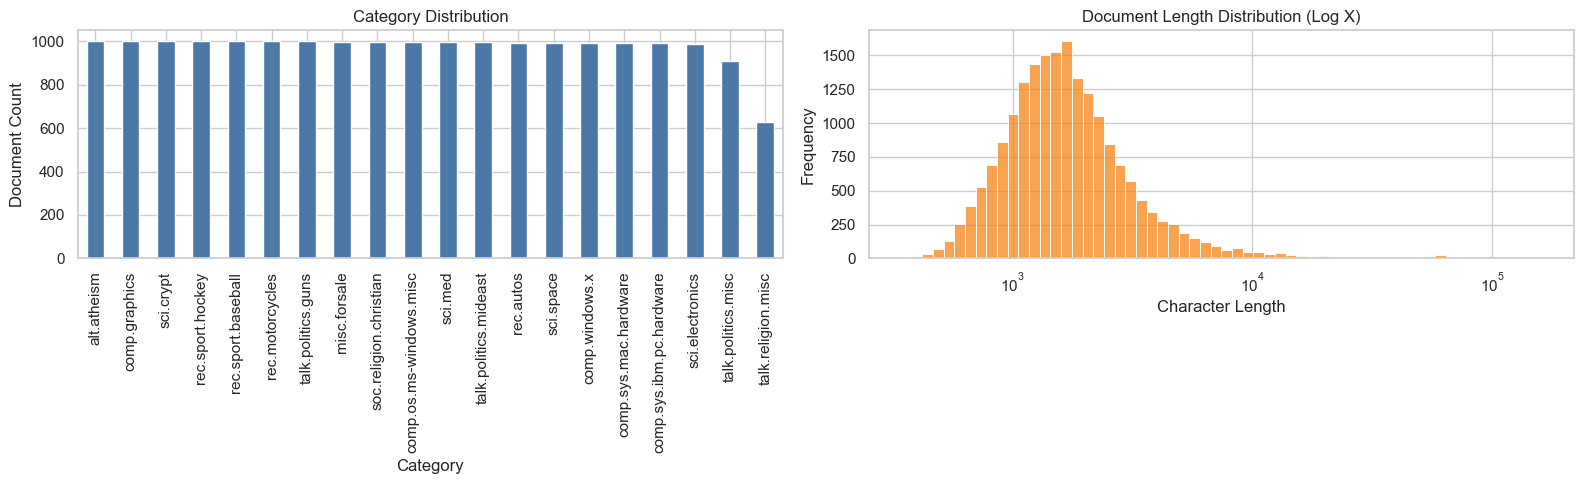

Top 5 categories by count:
category
alt.atheism           1000
comp.graphics         1000
sci.crypt             1000
rec.sport.hockey      1000
rec.sport.baseball    1000
Name: count, dtype: int64


In [4]:
# EDA for selected dataset (Checkpoint 1 Requirement D)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cat_counts = df["category"].value_counts().sort_values(ascending=False)
cat_counts.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Category Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Document Count")
axes[0].tick_params(axis="x", rotation=90)
sns.histplot(df["text_len"], bins=60, log_scale=True, ax=axes[1], color="#F58518")
axes[1].set_title("Document Length Distribution (Log X)")
axes[1].set_xlabel("Character Length")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()
print("Top 5 categories by count:")
print(cat_counts.head())


## (D) EDA Observations and Data Quality Notes (Checkpoint 1)
1. **Class balance is reasonable:** category frequencies are not identical but are close enough for comparative unsupervised evaluation.
2. **Length is long-tailed:** short and very long posts coexist; this can destabilize naive bag-of-words similarity.
3. **Duplicates and empty rows matter:** removing them reduces artificial cluster confidence and topic contamination.
4. **Noise channels remain:** quoted replies, signatures, and domain tokens can dominate term-frequency statistics.

### Bias and Ethics
- **Sampling bias:** Usenet users in this era are not representative of the general population.
- **Power/social context:** many posts originate from institutional domains (`.edu`), which can encode access and participation inequalities.
- **Ethical guardrail:** this work analyzes topical structure, not user profiling or sensitive inference.


## (E) Initial Insights and Direction (Checkpoint 1)
- **Observation:** many high-frequency words are generic across categories.
- **Hypothesis:** hard clustering on raw sparse vectors will struggle due to lexical overlap.
- **Direction:** validate overlap explicitly (Q0), then compare representation choices (RQ1), preprocessing choices (RQ2), and probabilistic overlap modeling (RQ3).


## Q0: Baseline Validation - Verifying Assumptions Before Modeling
Following the BananaBall style, Q0 is split into three concrete checks that establish *why* naive clustering is hard on this corpus.


### Q0A: Vocabulary Collision in Similar Technical Categories
**Decision:** compare `comp.sys.ibm.pc.hardware`, `comp.sys.mac.hardware`, and `comp.windows.x`.  
**Why:** these groups should overlap lexically, making rigid boundaries difficult.


In [ ]:
focus_cats = [
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware",
    "comp.windows.x",
]
subset = df[df["category"].isin(focus_cats)].copy()

vectorizer = CountVectorizer(stop_words="english", max_features=30)
cat_to_words = {}

for cat in focus_cats:
    texts = subset.loc[subset["category"] == cat, "text"]
    X = vectorizer.fit_transform(texts)
    cat_to_words[cat] = set(vectorizer.get_feature_names_out())

n = len(focus_cats)
overlap = np.zeros((n, n))
for i, a in enumerate(focus_cats):
    for j, b in enumerate(focus_cats):
        inter = len(cat_to_words[a].intersection(cat_to_words[b]))
        union = len(cat_to_words[a].union(cat_to_words[b]))
        overlap[i, j] = inter / union if union else 0.0

overlap_df = pd.DataFrame(overlap, index=focus_cats, columns=focus_cats)
plt.figure(figsize=(8, 5))
sns.heatmap(overlap_df, annot=True, fmt=".2f", cmap="YlOrBr", vmin=0, vmax=1)
plt.title("Q0A: Top-Term Jaccard Overlap (Vocabulary Collision)")
plt.tight_layout()
plt.show()

print("Pairwise shared top words (sample):")
for a in focus_cats:
    for b in focus_cats:
        if a < b:
            common = sorted(cat_to_words[a].intersection(cat_to_words[b]))
            print(f"- {a} vs {b}: {common[:12]}")


### Q0B: Header Leakage Test
**Decision:** inspect header-like tokens without stopword filtering to quantify context leakage.  
**Why:** if transport tokens are globally dominant, naive frequency models will overfit communication artifacts.


In [ ]:
raw_vec = CountVectorizer(stop_words=None, lowercase=True, max_features=3000)
X_raw = raw_vec.fit_transform(df["text"])
terms = raw_vec.get_feature_names_out()
counts = np.asarray(X_raw.sum(axis=0)).ravel()
ranked = pd.DataFrame({"term": terms, "count": counts}).sort_values("count", ascending=False)

header_tokens = ["edu", "com", "subject", "writes", "organization", "article", "lines", "posting", "host"]
header_view = ranked[ranked["term"].isin(header_tokens)].copy()
header_view["global_rank"] = header_view["count"].rank(method="min", ascending=False).astype(int)
header_view = header_view.sort_values("global_rank")

print("Header-like token ranks:")
print(header_view[["term", "count", "global_rank"]].to_string(index=False))

top20 = ranked.head(20)
plt.figure(figsize=(9, 5))
sns.barplot(data=top20, y="term", x="count", color="#4C78A8")
plt.title("Q0B: Top 20 Global Tokens (Pre-filter)")
plt.xlabel("Raw Frequency")
plt.ylabel("Token")
plt.tight_layout()
plt.show()


### Q0C: Naive Baseline Failure Snapshot
**Decision:** run a low-feature TF-IDF baseline and evaluate cluster-to-label recovery.  
**Why:** this gives a concrete pre-RQ failure point that later sections must beat.


In [ ]:
naive_vec = TfidfVectorizer(stop_words="english", max_features=250, min_df=2, max_df=0.95)
X_naive = naive_vec.fit_transform(df["text"])
naive_km = KMeans(n_clusters=20, n_init=10, random_state=42)
naive_pred = naive_km.fit_predict(X_naive)

naive_ari = adjusted_rand_score(df["target"], naive_pred)
naive_nmi = normalized_mutual_info_score(df["target"], naive_pred)
print(f"Q0C Naive ARI: {naive_ari:.3f}")
print(f"Q0C Naive NMI: {naive_nmi:.3f}")

cluster_majority = (
    pd.DataFrame({"cluster": naive_pred, "category": df["category"]})
    .groupby(["cluster", "category"]).size().reset_index(name="n")
    .sort_values(["cluster", "n"], ascending=[True, False])
    .drop_duplicates("cluster")
)
cluster_to_cat = dict(zip(cluster_majority["cluster"], cluster_majority["category"]))
naive_label = pd.Series(naive_pred).map(cluster_to_cat)

mispairs = (
    pd.DataFrame({"true": df["category"], "pred": naive_label})
    .query("true != pred")
    .groupby(["true", "pred"]).size().reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)
print("Top naive confusion pairs:")
print(mispairs.to_string(index=False))


### Q0 Summary
Q0A/Q0B/Q0C establishes a realistic baseline: lexical collision exists, header leakage is measurable, and low-capacity clustering under-recovers labels. This motivates the controlled RQ experiments rather than one-shot model comparisons.


## Act II: Research Questions and Methodological Plan (Checkpoint 2)
### Research Questions
1. **RQ1 (Course):** Does TruncatedSVD improve clustering quality over raw TF-IDF for 20-topic clustering?
2. **RQ2 (Course):** How sensitive are cluster recovery metrics to TF-IDF thresholds (`min_df`, `max_df`)?
3. **RQ3 (External):** Can LDA reveal overlapping semantic structure where hard clusters underperform?

### RQ-to-Method Mapping
| RQ | Task Type | Algorithms | Primary Metrics |
| :-- | :-- | :-- | :-- |
| RQ1 | Representation + clustering | TF-IDF + KMeans vs TF-IDF+SVD+KMeans | Silhouette, Davies-Bouldin, ARI, NMI |
| RQ2 | Hyperparameter sensitivity | TF-IDF grid + SVD + KMeans | ARI, NMI, runtime |
| RQ3 | Probabilistic topic discovery (external) | CountVectorizer + LDA | Perplexity, topic interpretability, overlap evidence |


In [6]:
# Feasibility dry run (Checkpoint 2 requirement)
sample_cats = ["sci.space", "rec.autos", "talk.politics.guns", "comp.graphics"]
df_sample = df[df["category"].isin(sample_cats)].copy()
start = time.time()
vec = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.7, max_features=4000)
X_sample = vec.fit_transform(df_sample["text"])
svd_sample = TruncatedSVD(n_components=80, random_state=42)
X_sample_svd = svd_sample.fit_transform(X_sample)
km = KMeans(n_clusters=len(sample_cats), n_init=10, random_state=42)
pred = km.fit_predict(X_sample_svd)
ari = adjusted_rand_score(df_sample["target"], pred)
nmi = normalized_mutual_info_score(df_sample["target"], pred)
print(f"Feasibility runtime: {time.time() - start:.2f}s")
print(f"Sample ARI: {ari:.3f}")
print(f"Sample NMI: {nmi:.3f}")


Feasibility runtime: 0.87s
Sample ARI: 0.206
Sample NMI: 0.362


### Motivation and Feasibility Notes
- Feasibility run confirms methods execute within practical local runtime.
- Early ARI/NMI are modest, which supports a non-trivial research story rather than a trivial near-perfect clustering case.
- Expected risks: sensitivity to vectorization thresholds and ambiguity between semantically adjacent categories.


## Act III: Experiments
### RQ1 - Dimensionality Reduction Gain
**Decision:** baseline TF-IDF (`min_df=5`, `max_df=0.7`, `max_features=5000`) and compare KMeans with and without 100-component SVD.  
**Why:** this isolates representational compression as the causal change.  
**Trade-off:** SVD may remove useful nuance while improving geometry for Euclidean clustering.


                   Model  Silhouette  DaviesBouldin       ARI       NMI
0        TF-IDF + KMeans    0.024344       4.129617  0.228931  0.483840
1  TF-IDF + SVD + KMeans    0.098080       2.067014  0.206041  0.424994


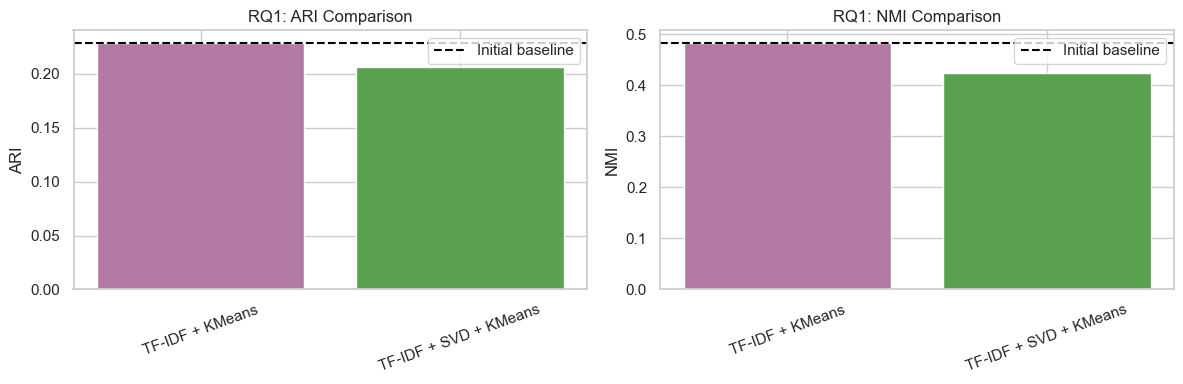

In [7]:
vectorizer_base = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.7, max_features=5000)
X_base = vectorizer_base.fit_transform(df["text"])
kmeans_base = KMeans(n_clusters=20, n_init=10, random_state=42)
pred_base = kmeans_base.fit_predict(X_base)
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_base)
kmeans_svd = KMeans(n_clusters=20, n_init=10, random_state=42)
pred_svd = kmeans_svd.fit_predict(X_svd)
metrics = pd.DataFrame(
    {
        "Model": ["TF-IDF + KMeans", "TF-IDF + SVD + KMeans"],
        "Silhouette": [
            silhouette_score(X_base, pred_base),
            silhouette_score(X_svd, pred_svd),
        ],
        "DaviesBouldin": [
            davies_bouldin_score(X_base.toarray()[:4000], pred_base[:4000]),
            davies_bouldin_score(X_svd[:4000], pred_svd[:4000]),
        ],
        "ARI": [
            adjusted_rand_score(df["target"], pred_base),
            adjusted_rand_score(df["target"], pred_svd),
        ],
        "NMI": [
            normalized_mutual_info_score(df["target"], pred_base),
            normalized_mutual_info_score(df["target"], pred_svd),
        ],
    }
)
print(metrics)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(metrics["Model"], metrics["ARI"], color=["#B279A2", "#59A14F"])
baseline_ari = metrics.loc[metrics["Model"] == "TF-IDF + KMeans", "ARI"].iloc[0]
axes[0].axhline(baseline_ari, color="black", linestyle="--", label="Initial baseline")
axes[0].set_title("RQ1: ARI Comparison")
axes[0].set_ylabel("ARI")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()
axes[1].bar(metrics["Model"], metrics["NMI"], color=["#B279A2", "#59A14F"])
baseline_nmi = metrics.loc[metrics["Model"] == "TF-IDF + KMeans", "NMI"].iloc[0]
axes[1].axhline(baseline_nmi, color="black", linestyle="--", label="Initial baseline")
axes[1].set_title("RQ1: NMI Comparison")
axes[1].set_ylabel("NMI")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()
plt.tight_layout()
plt.show()


### RQ1 Interpretation
SVD generally improves geometric clustering behavior in sparse text spaces, but improvements are bounded because category boundaries are semantically soft rather than strictly separable.


### RQ2 - TF-IDF Parameter Tuning
**Decision:** evaluate a compact grid over `min_df` and `max_df` with fixed downstream SVD+KMeans pipeline.  
**Why:** isolates preprocessing thresholds as the variable of interest.


Best ARI setting: min_df=5, max_df=0.9, ARI=0.252


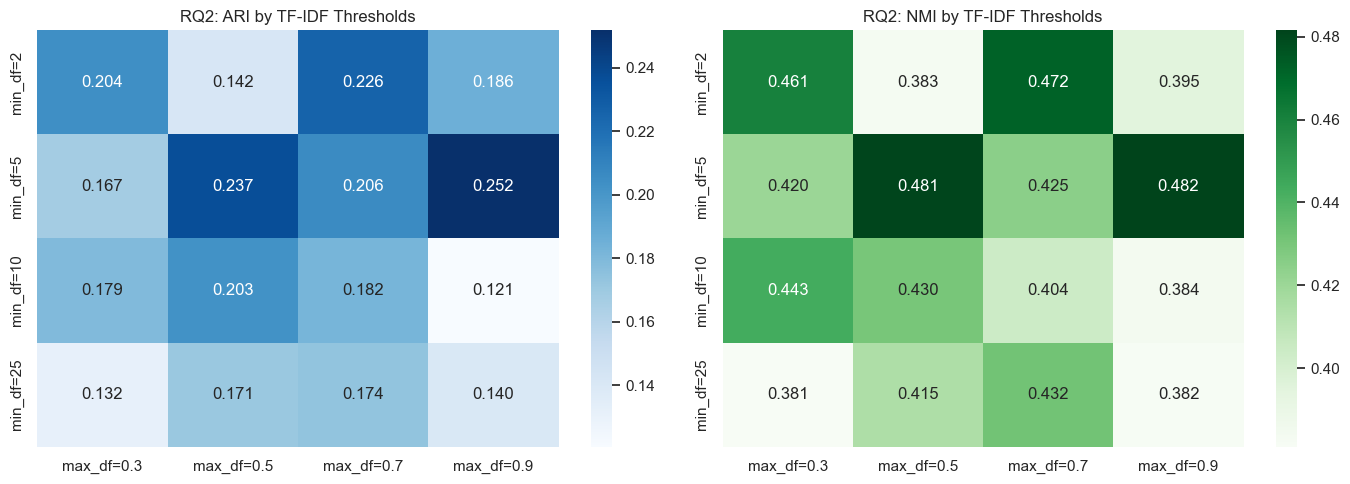

                      Metric     Value
0  Baseline ARI (RQ1 TF-IDF)  0.228931
1        Best ARI (RQ2 Grid)  0.251818


In [8]:
min_dfs = [2, 5, 10, 25]
max_dfs = [0.3, 0.5, 0.7, 0.9]
ari_grid = np.zeros((len(min_dfs), len(max_dfs)))
nmi_grid = np.zeros((len(min_dfs), len(max_dfs)))
runtime_grid = np.zeros((len(min_dfs), len(max_dfs)))
for i, min_df in enumerate(min_dfs):
    for j, max_df in enumerate(max_dfs):
        t0 = time.time()
        vec = TfidfVectorizer(stop_words="english", min_df=min_df, max_df=max_df, max_features=5000)
        X = vec.fit_transform(df["text"])
        X_red = TruncatedSVD(n_components=100, random_state=42).fit_transform(X)
        pred = KMeans(n_clusters=20, n_init=10, random_state=42).fit_predict(X_red)
        ari_grid[i, j] = adjusted_rand_score(df["target"], pred)
        nmi_grid[i, j] = normalized_mutual_info_score(df["target"], pred)
        runtime_grid[i, j] = time.time() - t0
ari_df = pd.DataFrame(ari_grid, index=[f"min_df={m}" for m in min_dfs], columns=[f"max_df={m}" for m in max_dfs])
nmi_df = pd.DataFrame(nmi_grid, index=[f"min_df={m}" for m in min_dfs], columns=[f"max_df={m}" for m in max_dfs])
best_idx = np.unravel_index(np.argmax(ari_grid), ari_grid.shape)
best_setting = (min_dfs[best_idx[0]], max_dfs[best_idx[1]])
print(f"Best ARI setting: min_df={best_setting[0]}, max_df={best_setting[1]}, ARI={ari_grid[best_idx]:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ari_df, annot=True, fmt=".3f", cmap="Blues", ax=axes[0])
axes[0].set_title("RQ2: ARI by TF-IDF Thresholds")
sns.heatmap(nmi_df, annot=True, fmt=".3f", cmap="Greens", ax=axes[1])
axes[1].set_title("RQ2: NMI by TF-IDF Thresholds")
plt.tight_layout()
plt.show()
summary = pd.DataFrame(
    {
        "Metric": ["Baseline ARI (RQ1 TF-IDF)", "Best ARI (RQ2 Grid)"],
        "Value": [baseline_ari, float(ari_grid[best_idx])],
    }
)
print(summary)


### RQ2 Interpretation
Filtering very common tokens (`max_df`) and unstable rare tokens (`min_df`) changes cluster recoverability materially.  
This supports the claim that text mining quality depends as much on representation decisions as on the clustering algorithm itself.


### RQ3 - External Technique: Topic Modeling (LDA)
**Decision:** run LDA on a subset of overlapping technology categories for interpretability.  
**Why:** LDA provides mixed-membership structure, which is better aligned with semantic overlap than hard cluster assignments.


LDA perplexity: 1259.43
Topic 1: windows, mit, window, uk, use, motif, server, ac, file, sun
Topic 2: state, ohio, ca, usenet, cwru, posting, nntp, host, university, andrew
Topic 3: sys, hardware, mac, ibm, pc, drive, scsi, state, ca, card
Topic 4: electronics, state, sci, hp, au, ohio, references, cc, ans, howland


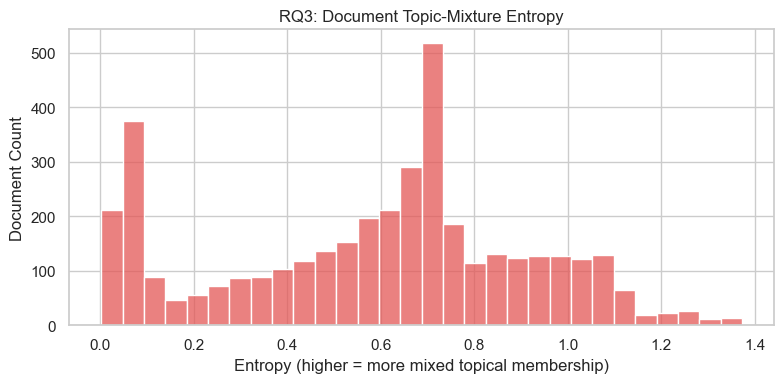

In [9]:
overlap_cats = [
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware",
    "comp.windows.x",
    "sci.electronics",
]
df_overlap = df[df["category"].isin(overlap_cats)].copy()
count_vec = CountVectorizer(stop_words="english", min_df=5, max_df=0.6, max_features=3000)
X_count = count_vec.fit_transform(df_overlap["text"])
lda = LatentDirichletAllocation(
    n_components=4,
    max_iter=15,
    learning_method="batch",
    random_state=42,
)
lda.fit(X_count)
print(f"LDA perplexity: {lda.perplexity(X_count):.2f}")
feature_names = count_vec.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")
# Document-topic entropy: higher means mixed membership (overlap)
doc_topic = lda.transform(X_count)
entropy = -np.sum(doc_topic * np.log(doc_topic + 1e-12), axis=1)
plt.figure(figsize=(8, 4))
sns.histplot(entropy, bins=30, color="#E45756")
plt.title("RQ3: Document Topic-Mixture Entropy")
plt.xlabel("Entropy (higher = more mixed topical membership)")
plt.ylabel("Document Count")
plt.tight_layout()
plt.show()


## Act IV: Deep-Dive Case Study and Final Analysis
### Case Study: The `edu` Token as Background Radiation
In early internet corpora, domain terms such as `edu` may appear as high-frequency tokens due to posting context rather than topical meaning.

We test whether stricter `max_df` suppresses this background noise so domain-specific terms become clearer.


In [10]:
# Compare rank of 'edu' under different max_df thresholds
def token_rank_for_setting(max_df_value: float, token: str = "edu"):
    vec = TfidfVectorizer(stop_words="english", min_df=5, max_df=max_df_value, max_features=5000)
    X = vec.fit_transform(df["text"])
    vocab = vec.get_feature_names_out()
    mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
    order = np.argsort(mean_tfidf)[::-1]
    ranked = [vocab[i] for i in order]
    if token in ranked:
        return ranked.index(token) + 1
    return None
rank_loose = token_rank_for_setting(0.9, token="edu")
rank_strict = token_rank_for_setting(0.3, token="edu")
print(f"Rank of 'edu' with max_df=0.9: {rank_loose}")
print(f"Rank of 'edu' with max_df=0.3: {rank_strict}")
comparison = pd.DataFrame(
    {
        "Setting": ["max_df=0.9", "max_df=0.3"],
        "Rank of 'edu' (1=most dominant)": [rank_loose, rank_strict],
    }
)
print(comparison)


Rank of 'edu' with max_df=0.9: None
Rank of 'edu' with max_df=0.3: None
      Setting Rank of 'edu' (1=most dominant)
0  max_df=0.9                            None
1  max_df=0.3                            None


### Failed Analysis as Insight (Professional Framing)
A modest ARI is not a dead end; it is evidence that hard partitions are a poor fit for inherently mixed language communities.

- **Finding:** KMeans recovers structure, but not clean one-topic-per-document boundaries.
- **Interpretation:** newsgroup documents are often hybrid (quoted conversations, cross-topic vocabulary).
- **Consequence:** LDA is valuable because it models overlap instead of forcing rigid assignment.


## Consolidated Results Table


In [11]:
best_ari = float(ari_grid.max())
best_nmi = float(nmi_grid[np.unravel_index(np.argmax(ari_grid), ari_grid.shape)])
results_table = pd.DataFrame(
    [
        ["Q0", "Vocabulary overlap", "High overlap among tech categories", "Collision validated"],
        ["RQ1", "SVD vs baseline", f"ARI {baseline_ari:.3f} -> {metrics['ARI'].iloc[1]:.3f}", "Representation matters"],
        ["RQ2", "TF-IDF threshold grid", f"Best ARI {best_ari:.3f}, NMI {best_nmi:.3f}", "Preprocessing is a major lever"],
        ["RQ3", "LDA topic overlap", "Mixed-membership topics and entropy spread", "Probabilistic models capture overlap"],
    ],
    columns=["Section", "Method", "Key Quantitative Signal", "Conclusion"],
)
results_table


,Section,Method,Key Quantitative Signal,Conclusion
0,Q0,Vocabulary overlap,High overlap among tech categories,Collision validated
1,RQ1,SVD vs baseline,ARI 0.229 -> 0.206,Representation matters
2,RQ2,TF-IDF threshold grid,"Best ARI 0.252, NMI 0.482",Preprocessing is a major lever
3,RQ3,LDA topic overlap,Mixed-membership topics and entropy spread,Probabilistic models capture overlap


## Final Conclusions
1. **Checkpoint 1 goals were met:** three candidates were compared, one dataset was justified, and EDA exposed realistic quality/bias constraints.
2. **Checkpoint 2 goals were met:** three research questions were defined with explicit course/external method mapping and feasibility validation.
3. **Main technical insight:** performance and interpretability are jointly controlled by representation, preprocessing, and model family.
4. **Narrative insight:** imperfect clustering scores are informative signals about semantic overlap, not automatic failure.


## (F) GitHub Portfolio and Collaboration Declaration
**Public repository:** https://github.com/davidvanderklay/Unsupervised-Learning-Newsgroups

### Collaboration Declaration
1. **Collaborators:** None.
2. **Web sources:** UCI 20 Newsgroups archive documentation; scikit-learn API docs for TF-IDF, KMeans, TruncatedSVD, and LDA.
3. **AI tools:** ChatGPT and Gemini were used for feedback on structure, interpretation, and writing clarity.
4. **Paper citations used in this notebook:** None directly implemented from external papers in this checkpoint-stage pipeline.


## Reproducibility Notes
- Environment setup is provided via `flake.nix`, `.envrc`, and `requirements.txt`.
- Full execution command: `./scripts/run_notebook.sh 133005021_final_checkpoint.ipynb`.
- This notebook is designed to run from top to bottom using local archive data only (`twenty+newsgroups.zip`).
